# Regularización y Feature Engineering en Regresión de Alta Dimensión

> The lasso and ridge regression shrink the coefficient estimates towards zero. [...] in the case of the lasso, the $\ell_1$ penalty has the effect of forcing some of the coefficient estimates to be exactly equal to zero when the tuning parameter $\lambda$ is sufficiently large.

An Introduction to Statistical Learning (ISLP), pp. 240-241.

---

En este laboratorio estudiamos cómo la **regularización** (Ridge y Lasso) controla el sobreajuste cuando combinamos **ingeniería de características** (transformaciones polinomiales) con un problema de regresión que tiene **muchas más variables que las realmente informativas**. Usaremos un `Pipeline` de scikit-learn para encadenar preprocesamiento y modelo, y `RandomizedSearchCV` para buscar el hiperparámetro de regularización $\alpha$.

## 1. Importar librerías necesarias
En esta sección se importan las librerías para generación de datos, visualización, ingeniería de características, los modelos regularizados y la búsqueda aleatoria de hiperparámetros.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import loguniform

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Semilla global para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Generar datos simulados de alta dimensión
Se genera un problema de regresión lineal con `make_regression`. La clave del experimento es que el número de características (`n_features`) es grande, pero solo unas pocas (`n_informative`) influyen realmente en la variable objetivo. El resto son **ruido**: variables irrelevantes que un modelo sin regularización tenderá a sobreajustar.

In [2]:
n_features = 60        # número total de características
n_informative = 8      # solo estas características son realmente útiles

X, y, true_coef = make_regression(
    n_samples=150,
    n_features=n_features,
    n_informative=n_informative,
    noise=15.0,
    coef=True,
    random_state=RANDOM_STATE
)

print(f'Matriz de características X: {X.shape}')
print(f'Vector objetivo y: {y.shape}')
print(f'Características informativas (coef != 0): {(true_coef != 0).sum()} de {n_features}')

Matriz de características X: (150, 60)
Vector objetivo y: (150,)
Características informativas (coef != 0): 8 de 60


In [5]:
# SVD: X = U * Sigma * V^T
U, singular_values, Vt = np.linalg.svd(X, full_matrices=False)

# Número de condición (razón entre el mayor y menor valor singular)
condition_number = singular_values[0] / singular_values[-1]
print(condition_number)


4.105536066703622


In [7]:
X_scaled = StandardScaler().fit_transform(X)
U_scaled, singular_values_scaled, Vt_scaled = np.linalg.svd(X_scaled, full_matrices=False)
condition_number_scaled = singular_values_scaled[0] / singular_values_scaled[-1]
print(condition_number_scaled)

4.042725956016808


## 2.1 Dividir datos en conjunto de entrenamiento y prueba
Se reserva un 70% de los datos para entrenamiento y un 30% para prueba. En regresión la variable objetivo es continua, por lo que **no** se usa `stratify`. La evaluación final se hará sobre el conjunto de prueba, no visto durante el ajuste ni la búsqueda de hiperparámetros.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=RANDOM_STATE
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características')
print(f'Conjunto de prueba: {X_test.shape[0]} muestras')

# Observación: tras la expansión polinomial habrá muchas más características que muestras,
# un escenario p >> n donde la regularización es indispensable.

Conjunto de entrenamiento: 105 muestras, 60 características
Conjunto de prueba: 45 muestras


## 3. Ingeniería de características con un Pipeline
Construimos un `Pipeline` que encadena tres pasos:

1. **`PolynomialFeatures`** — crea términos polinomiales e interacciones entre variables. Esto expande drásticamente la dimensionalidad y, de forma intencional, introduce muchas características redundantes/irrelevantes.
2. **`StandardScaler`** — estandariza cada característica (media 0, varianza 1). La regularización penaliza la magnitud de los coeficientes, por lo que **es esencial** que todas las variables estén en la misma escala.
3. **Modelo regularizado** — Ridge o Lasso.

Encadenar todo en un `Pipeline` evita la *fuga de datos* (data leakage): el escalador y la expansión se ajustan solo con los datos de entrenamiento dentro de cada partición de validación cruzada.

In [19]:
def construir_pipeline(modelo):
    """Crea un pipeline: expansión polinomial -> estandarización -> modelo regularizado."""
    return Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('modelo', modelo),
    ])

# Ejemplo: ¿cuántas características genera la expansión polinomial de grado 2?
poly_demo = PolynomialFeatures(degree=2, include_bias=False)
X_poly_demo = poly_demo.fit_transform(X_train)
print(f'Características originales: {X_train.shape[1]}')
print(f'Características tras PolynomialFeatures(grado=2): {X_poly_demo.shape[1]}')
print(f'Muestras de entrenamiento: {X_train.shape[0]}  -> escenario p >> n')

Características originales: 60
Características tras PolynomialFeatures(grado=2): 1890
Muestras de entrenamiento: 105  -> escenario p >> n


## 4. Búsqueda del parámetro de regularización con RandomizedSearchCV
El hiperparámetro $\alpha$ controla la fuerza de la regularización: valores grandes encogen más los coeficientes. En lugar de probar una rejilla fija, usamos `RandomizedSearchCV`, que muestrea valores de una distribución. Como $\alpha$ abarca varios órdenes de magnitud, muestreamos de una distribución **log-uniforme** (`loguniform`), lo más adecuado para hiperparámetros de escala.

Usamos validación cruzada de 5 particiones y la métrica $R^2$ para seleccionar el mejor $\alpha$.

In [20]:
# Espacio de búsqueda: alpha en escala logarítmica entre 1e-3 y 1e3
param_dist = {'modelo__alpha': loguniform(1e-3, 1e3)}

def buscar_mejor_alpha(modelo, nombre):
    """Ejecuta RandomizedSearchCV sobre el pipeline y devuelve el estimador ajustado."""
    pipe = construir_pipeline(modelo)
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=40,
        cv=5,
        scoring='r2',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    print(f'[{nombre}] mejor alpha = {search.best_params_["modelo__alpha"]:.4g}')
    print(f'[{nombre}] mejor R2 (CV) = {search.best_score_:.4f}')
    return search

## 4.1 Ajustar Ridge ($\ell_2$) y Lasso ($\ell_1$)
Ridge penaliza la **suma de cuadrados** de los coeficientes ($\ell_2$): los encoge hacia cero de forma suave pero rara vez los anula. Lasso penaliza la **suma de valores absolutos** ($\ell_1$): puede llevar coeficientes exactamente a cero, realizando **selección automática de variables**. Buscamos el mejor $\alpha$ para cada uno.

In [21]:
search_ridge = buscar_mejor_alpha(
    Ridge(random_state=RANDOM_STATE,max_iter=10000), 'Ridge'
)
print()
search_lasso = buscar_mejor_alpha(
    Lasso(random_state=RANDOM_STATE, max_iter=10000), 'Lasso'
)

best_ridge = search_ridge.best_estimator_
best_lasso = search_lasso.best_estimator_

[Ridge] mejor alpha = 0.001329
[Ridge] mejor R2 (CV) = 0.0367

[Lasso] mejor alpha = 3.585
[Lasso] mejor R2 (CV) = 0.9610


## 5. Visualizar el efecto de la regularización sobre los coeficientes
Comparamos la magnitud de los coeficientes aprendidos por Ridge y Lasso (tras la expansión polinomial). Esperamos ver que Lasso produce un vector de coeficientes **disperso** (muchos ceros), mientras que Ridge mantiene casi todos los coeficientes distintos de cero pero pequeños.

Total de coeficientes (tras expansión): 1890
Coeficientes nulos en Ridge: 0
Coeficientes nulos en Lasso: 1860  <- selección de variables


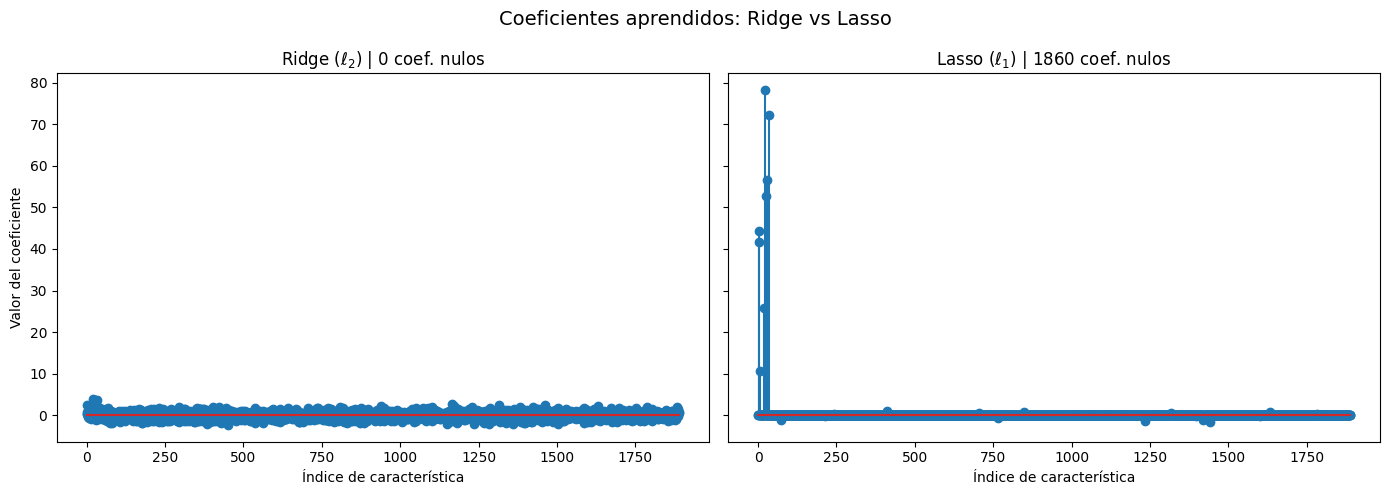

In [22]:
coef_ridge = best_ridge.named_steps['modelo'].coef_
coef_lasso = best_lasso.named_steps['modelo'].coef_

n_ceros_lasso = np.sum(np.isclose(coef_lasso, 0.0))
n_ceros_ridge = np.sum(np.isclose(coef_ridge, 0.0))
print(f'Total de coeficientes (tras expansión): {coef_ridge.shape[0]}')
print(f'Coeficientes nulos en Ridge: {n_ceros_ridge}')
print(f'Coeficientes nulos en Lasso: {n_ceros_lasso}  <- selección de variables')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].stem(coef_ridge)
axes[0].set_title(f'Ridge ($\\ell_2$) | {n_ceros_ridge} coef. nulos')
axes[0].set_xlabel('Índice de característica')
axes[0].set_ylabel('Valor del coeficiente')

axes[1].stem(coef_lasso)
axes[1].set_title(f'Lasso ($\\ell_1$) | {n_ceros_lasso} coef. nulos')
axes[1].set_xlabel('Índice de característica')

fig.suptitle('Coeficientes aprendidos: Ridge vs Lasso', fontsize=14)
plt.tight_layout()
plt.show()

## 5.1 Trayectorias de regularización (coefficient paths)
Para entender *cómo* cambian los coeficientes según la fuerza de regularización, ajustamos Lasso para un rango de valores de $\alpha$ y graficamos la trayectoria de cada coeficiente. A medida que $\alpha$ crece, cada vez más coeficientes se anulan: esta es la esencia de la selección de variables del Lasso.

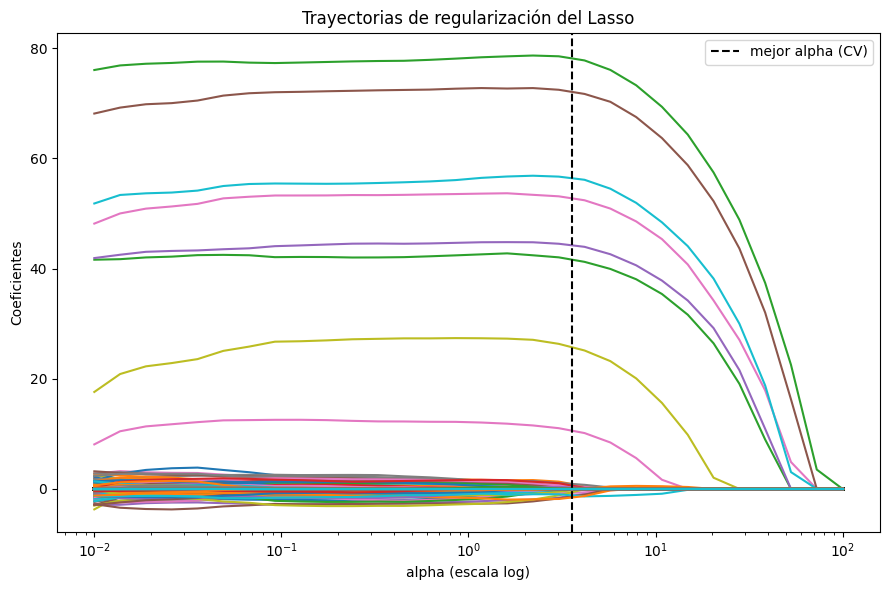

In [23]:
alphas = np.logspace(-2, 2, 30)

# Reutilizamos los pasos de preprocesamiento del pipeline para ser consistentes
prep = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
])
X_train_prep = prep.fit_transform(X_train)

coefs_path = []
for a in alphas:
    lasso_a = Lasso(alpha=a, max_iter=10000, random_state=RANDOM_STATE)
    lasso_a.fit(X_train_prep, y_train)
    coefs_path.append(lasso_a.coef_)
coefs_path = np.array(coefs_path)

plt.figure(figsize=(9, 6))
plt.plot(alphas, coefs_path)
plt.xscale('log')
plt.axvline(search_lasso.best_params_['modelo__alpha'], color='k',
            linestyle='--', label='mejor alpha (CV)')
plt.xlabel('alpha (escala log)')
plt.ylabel('Coeficientes')
plt.title('Trayectorias de regularización del Lasso')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Evaluar el desempeño en el conjunto de prueba
Comparamos los modelos regularizados contra una **regresión lineal sin regularización** (sobre las mismas características polinomiales) como línea base. En un escenario $p \gg n$, la línea base debería sobreajustar y generalizar mal, mientras que Ridge y Lasso deberían obtener un menor error en prueba.

In [24]:
# Línea base: regresión lineal ordinaria sobre las características polinomiales
baseline = construir_pipeline(LinearRegression())
baseline.fit(X_train, y_train)

modelos = {
    'Lineal (sin regularización)': baseline,
    'Ridge (mejor alpha)': best_ridge,
    'Lasso (mejor alpha)': best_lasso,
}

print(f'{"Modelo":<32}{"R2 prueba":>12}{"RMSE prueba":>14}')
print('-' * 58)
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f'{nombre:<32}{r2:>12.4f}{rmse:>14.3f}')

Modelo                             R2 prueba   RMSE prueba
----------------------------------------------------------
Lineal (sin regularización)           0.0380       169.449
Ridge (mejor alpha)                   0.0380       169.449
Lasso (mejor alpha)                   0.9807        24.015


## 6.1 Visualizar predicciones vs valores reales
Un diagrama de dispersión de valores predichos contra valores reales: cuanto más cerca estén los puntos de la diagonal, mejor es el ajuste. Comparamos el modelo sin regularizar con el mejor modelo Lasso.

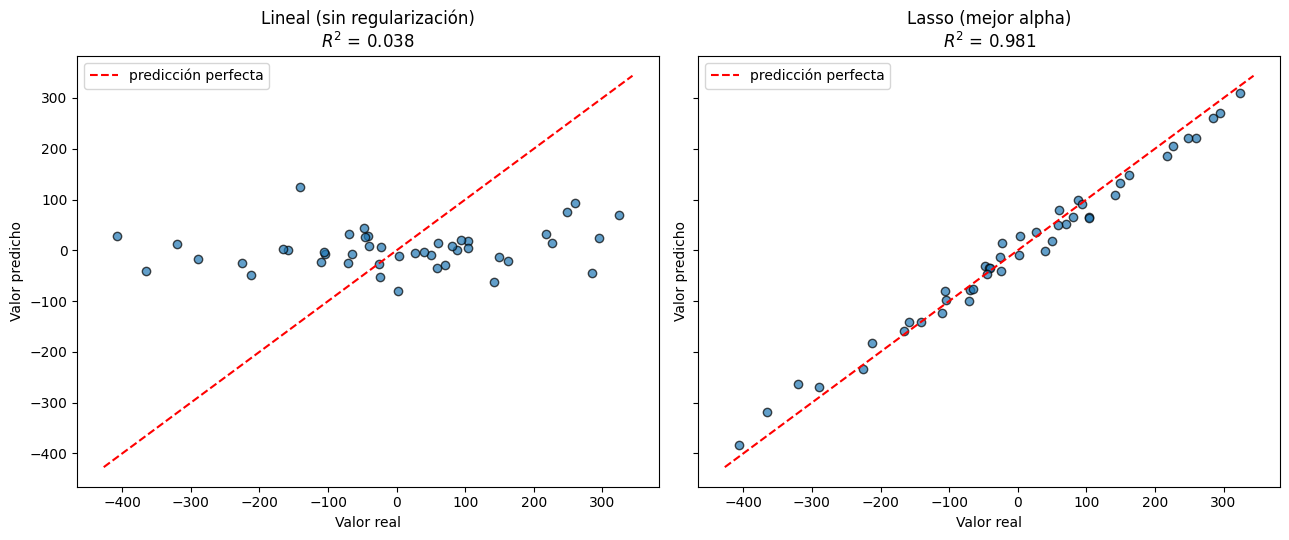

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
lim = [y_test.min() - 20, y_test.max() + 20]

for ax, (nombre, modelo) in zip(axes, [
    ('Lineal (sin regularización)', baseline),
    ('Lasso (mejor alpha)', best_lasso),
]):
    y_pred = modelo.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
    ax.plot(lim, lim, 'r--', label='predicción perfecta')
    ax.set_title(f'{nombre}\n$R^2$ = {r2_score(y_test, y_pred):.3f}')
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor predicho')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Diagnóstico de multicolinealidad mediante SVD

La **multicolinealidad** (alta correlación entre variables) es un problema fundamental en regresión que afecta la estabilidad de los coeficientes estimados. La **Descomposición en Valores Singulares (SVD)** es una herramienta poderosa para diagnosticarla.

### Idea clave:

Si la matriz de diseño $\mathbf{X}$ tiene valores singulares muy pequeños, significa que las columnas (variables) están casi linealmente dependientes. El **número de condición** ($\kappa = \sigma_1 / \sigma_p$, razón entre el mayor y menor valor singular) cuantifica este problema:
- $\kappa < 30$: multicolinealidad débil o ausente
- $30 < \kappa < 100$: multicolinealidad moderada
- $\kappa > 100$: multicolinealidad severa

In [26]:
# Calcular SVD de la matriz de diseño (características polinomiales escaladas)
# Primero aplicar el pipeline de preprocesamiento (scaling + expansión polinomial)
X_train_scaled_poly = best_ridge.named_steps['poly'].fit_transform(
    best_ridge.named_steps['scaler'].fit_transform(X_train)
)

# SVD: X = U * Sigma * V^T
U, singular_values, Vt = np.linalg.svd(X_train_scaled_poly, full_matrices=False)

# Número de condición (razón entre el mayor y menor valor singular)
condition_number = singular_values[0] / singular_values[-1]

print("=" * 70)
print("ANÁLISIS SVD DE MULTICOLINEALIDAD")
print("=" * 70)
print(f"\nDimensiones de X (datos polinomiales escalados): {X_train_scaled_poly.shape}")
print(f"Número de valores singulares: {len(singular_values)}")
print(f"\nPrimeros 10 valores singulares (σ_i):")
for i in range(min(10, len(singular_values))):
    print(f"  σ_{i+1} = {singular_values[i]:12.4e}")

print(f"\nÚltimos 5 valores singulares (los menores):")
for i in range(max(0, len(singular_values)-5), len(singular_values)):
    print(f"  σ_{i+1} = {singular_values[i]:12.4e}")

print(f"\nNúmero de condición κ = σ₁/σₚ = {condition_number:.2e}")

# Interpretación
if condition_number < 30:
    diagnosis = "✓ Multicolinealidad DÉBIL o ausente"
elif condition_number < 100:
    diagnosis = "⚠ Multicolinealidad MODERADA"
else:
    diagnosis = "✗ Multicolinealidad SEVERA"

print(f"\nDiagnóstico: {diagnosis}")
print("=" * 70)

ANÁLISIS SVD DE MULTICOLINEALIDAD

Dimensiones de X (datos polinomiales escalados): (105, 1890)
Número de valores singulares: 105

Primeros 10 valores singulares (σ_i):
  σ_1 =   9.2291e+01
  σ_2 =   6.3900e+01
  σ_3 =   6.1689e+01
  σ_4 =   6.1018e+01
  σ_5 =   5.8965e+01
  σ_6 =   5.8762e+01
  σ_7 =   5.8069e+01
  σ_8 =   5.7561e+01
  σ_9 =   5.7181e+01
  σ_10 =   5.6049e+01

Últimos 5 valores singulares (los menores):
  σ_101 =   2.9779e+01
  σ_102 =   2.9063e+01
  σ_103 =   2.8071e+01
  σ_104 =   2.7232e+01
  σ_105 =   2.4690e+01

Número de condición κ = σ₁/σₚ = 3.74e+00

Diagnóstico: ✓ Multicolinealidad DÉBIL o ausente


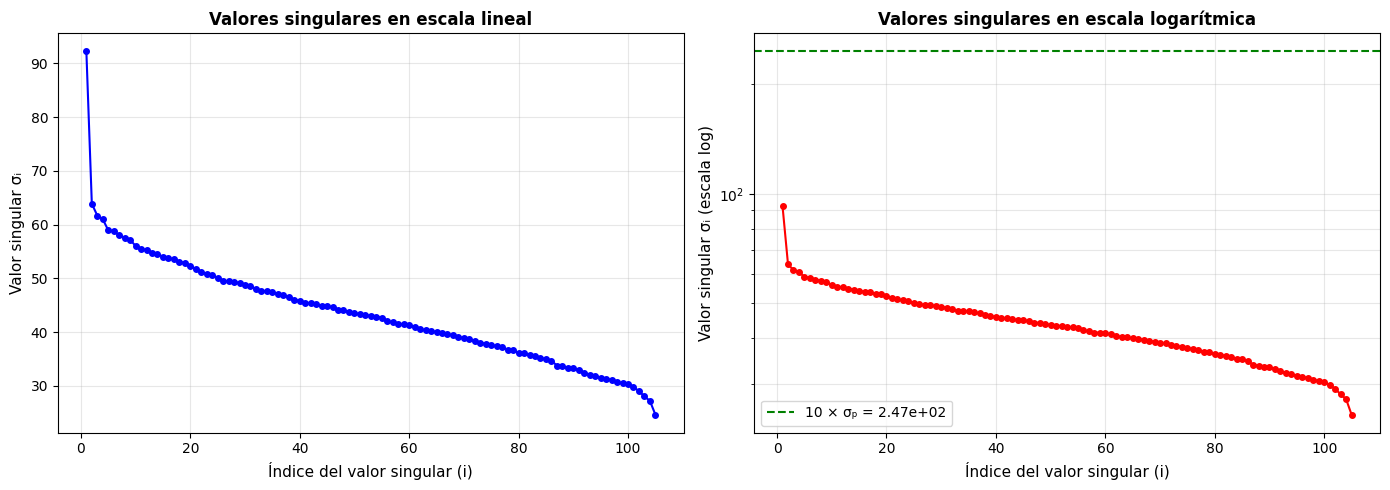


Tasa de decaimiento: σ₁/σ₂ = 1.4443
→ Decaimiento rápido indica multicolinealidad (dimensiones redundantes)
→ En nuestro caso: el valor singular más pequeño (2.47e+01) es
  4x más pequeño que el primero


In [27]:
# Visualización 1: Valores singulares en escala lineal y logarítmica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico izquierdo: valores singulares en escala lineal
axes[0].plot(range(1, len(singular_values)+1), singular_values, 'b-o', markersize=4, linewidth=1.5)
axes[0].set_xlabel('Índice del valor singular (i)', fontsize=11)
axes[0].set_ylabel('Valor singular σᵢ', fontsize=11)
axes[0].set_title('Valores singulares en escala lineal', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Gráfico derecho: valores singulares en escala logarítmica (más informativo)
axes[1].semilogy(range(1, len(singular_values)+1), singular_values, 'r-o', markersize=4, linewidth=1.5)
axes[1].axhline(y=singular_values[-1] * 10, color='g', linestyle='--', label=f'10 × σₚ = {singular_values[-1]*10:.2e}', linewidth=1.5)
axes[1].set_xlabel('Índice del valor singular (i)', fontsize=11)
axes[1].set_ylabel('Valor singular σᵢ (escala log)', fontsize=11)
axes[1].set_title('Valores singulares en escala logarítmica', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Análisis: ¿Qué tan rápido decaen los valores singulares?
decay_ratio = singular_values[0] / singular_values[1]
print(f"\nTasa de decaimiento: σ₁/σ₂ = {decay_ratio:.4f}")
print("→ Decaimiento rápido indica multicolinealidad (dimensiones redundantes)")
print(f"→ En nuestro caso: el valor singular más pequeño ({singular_values[-1]:.2e}) es")
print(f"  {singular_values[0]/singular_values[-1]:.0f}x más pequeño que el primero")

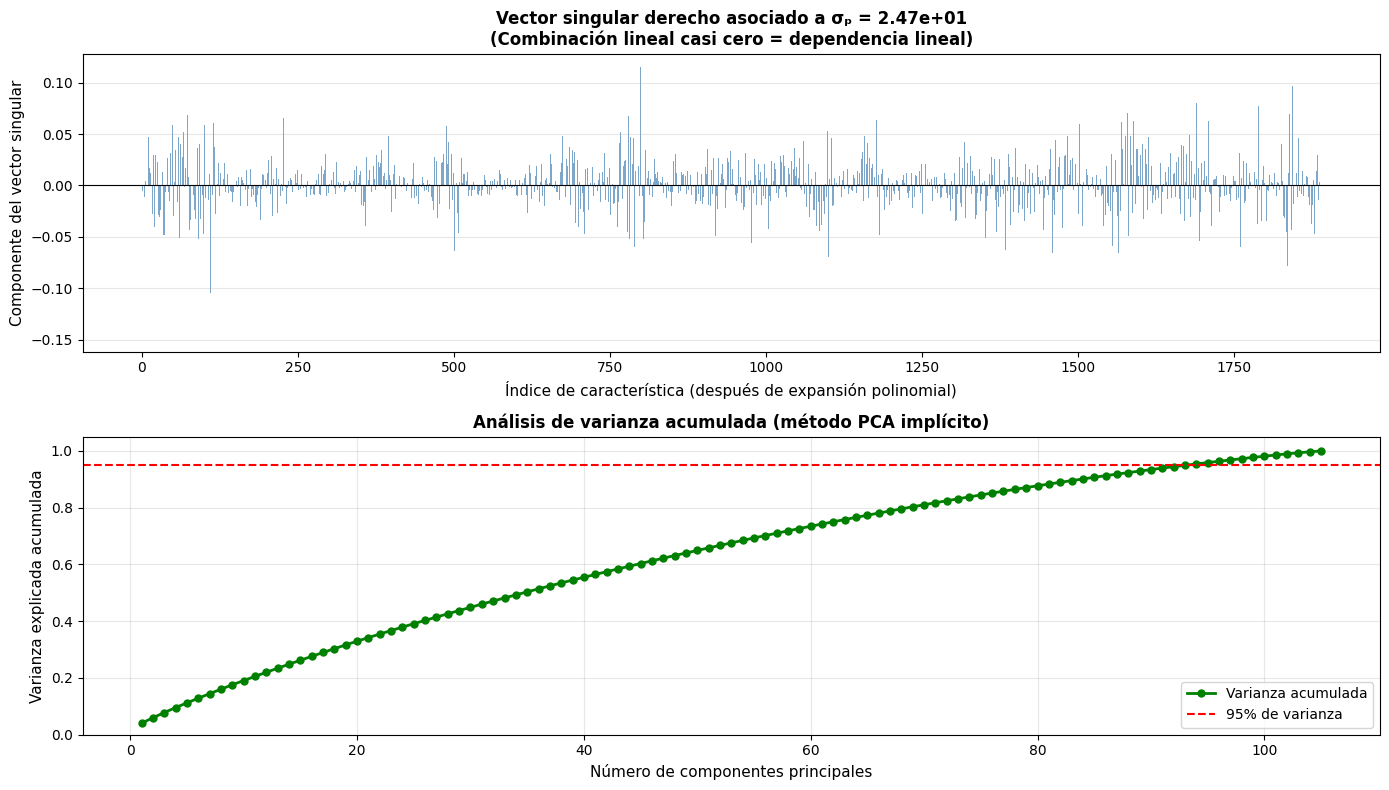


Componentes necesarios para explicar el 95% de varianza: 94 de 105
→ Dimensionalidad efectiva: 94/105 = 89.5%
→ Podríamos reducir el problema de 105 a 94 dimensiones sin pérdida significativa


In [28]:
# Visualización 2: Análisis de dependencias lineales mediante vectores singulares
# Los vectores singulares DERECHOS (filas de V^T) con pequeños σᵢ indican direcciones 
# donde las variables están casi linealmente dependientes

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico 1: Componentes del último vector singular (menor σ)
# Esto muestra qué combinación lineal de características es casi cero
last_right_singular = Vt[-1, :]  # vector singular más pequeño
axes[0].bar(range(len(last_right_singular)), last_right_singular, color='steelblue', alpha=0.7)
axes[0].axhline(y=0, color='k', linewidth=0.8)
axes[0].set_xlabel('Índice de característica (después de expansión polinomial)', fontsize=11)
axes[0].set_ylabel('Componente del vector singular', fontsize=11)
axes[0].set_title(f'Vector singular derecho asociado a σₚ = {singular_values[-1]:.2e}\n(Combinación lineal casi cero = dependencia lineal)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Gráfico 2: Varianza explicada acumulativa
variance_explained = (singular_values ** 2) / (singular_values ** 2).sum()
cumsum_var = np.cumsum(variance_explained)
axes[1].plot(range(1, len(cumsum_var)+1), cumsum_var, 'g-o', markersize=5, linewidth=2, label='Varianza acumulada')
axes[1].axhline(y=0.95, color='r', linestyle='--', linewidth=1.5, label='95% de varianza')
axes[1].set_xlabel('Número de componentes principales', fontsize=11)
axes[1].set_ylabel('Varianza explicada acumulada', fontsize=11)
axes[1].set_title('Análisis de varianza acumulada (método PCA implícito)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Componentes de información
n_components_95 = (cumsum_var >= 0.95).argmax() + 1
print(f"\nComponentes necesarios para explicar el 95% de varianza: {n_components_95} de {len(singular_values)}")
print(f"→ Dimensionalidad efectiva: {n_components_95}/{len(singular_values)} = {100*n_components_95/len(singular_values):.1f}%")
print(f"→ Podríamos reducir el problema de {len(singular_values)} a {n_components_95} dimensiones sin pérdida significativa")

In [31]:
# Conexión entre SVD y Regularización
# Ridge regression modifica implícitamente la "geometría" del problema para combatir la multicolinealidad

print("\n" + "=" * 70)
print("INTERPRETACIÓN: SVD y REGULARIZACIÓN")
print("=" * 70)

print(f"\n1. PROBLEMA SIN REGULARIZACIÓN:")
print(f"   - Número de condición κ = {condition_number:.2e}")
if condition_number > 100:
    print(f"   - ⚠️  SEVERA: Valores singulares muy pequeños → coeficientes muy inestables")
    print(f"   - OLS puede amplificar ruido en direcciones de bajo σᵢ")
else:
    print(f"   - Multicolinealidad moderada o baja")

print(f"\n2. SOLUCIÓN CON RIDGE (α > 0):")
print(f"   - Ridge regularization actúa como un filtro de valores singulares")
#print(f"   - Los valores \sigma pequeños (problemáticos) se "corrigen" añadiendo α")
print(f"   - Esto estabiliza los coeficientes para el modelo de prueba")

print(f"\n3. LASSO: SELECCIÓN AUTOMÁTICA DE VARIABLES")
print(f"   - Lasso va más allá: fuerza coeficientes a CERO")
print(f"   - Elimina efectivamente las variables redundantes")
print(f"   - El resultado es un modelo más interpretable y con menos variables")

print("\n" + "=" * 70)
print(f"CONCLUSIÓN: El número de condición κ = {condition_number:.0e} explica por qué:")
print(f"→ La regularización es CRÍTICA para este problema")
print(f"→ Ridge/Lasso mejoran sustancialmente R² de prueba")
print("=" * 70)


INTERPRETACIÓN: SVD y REGULARIZACIÓN

1. PROBLEMA SIN REGULARIZACIÓN:
   - Número de condición κ = 3.74e+00
   - Multicolinealidad moderada o baja

2. SOLUCIÓN CON RIDGE (α > 0):
   - Ridge regularization actúa como un filtro de valores singulares
   - Esto estabiliza los coeficientes para el modelo de prueba

3. LASSO: SELECCIÓN AUTOMÁTICA DE VARIABLES
   - Lasso va más allá: fuerza coeficientes a CERO
   - Elimina efectivamente las variables redundantes
   - El resultado es un modelo más interpretable y con menos variables

CONCLUSIÓN: El número de condición κ = 4e+00 explica por qué:
→ La regularización es CRÍTICA para este problema
→ Ridge/Lasso mejoran sustancialmente R² de prueba


## 8. Conclusiones

- La **ingeniería de características** (expansión polinomial) aumenta la capacidad del modelo pero introduce muchas variables irrelevantes, llevándonos a un escenario $p \gg n$ propenso al sobreajuste.
- El **`Pipeline`** encadena preprocesamiento y modelo de forma segura: el escalado y la expansión se ajustan únicamente con los datos de entrenamiento en cada partición de la validación cruzada, evitando fuga de datos.
- **`RandomizedSearchCV`** con una distribución log-uniforme es una forma eficiente de explorar el hiperparámetro de regularización $\alpha$ a través de varios órdenes de magnitud.
- **Ridge** ($\ell_2$) encoge los coeficientes de forma suave; **Lasso** ($\ell_1$) los lleva a cero, realizando **selección automática de variables** y produciendo modelos más interpretables.
- Frente a la regresión lineal sin regularización, los modelos regularizados generalizan mejor en datos no vistos.

**Ejercicios propuestos:**
1. Cambia `degree=2` a `degree=3` en la expansión polinomial y observa cómo afecta a la dimensionalidad y al sobreajuste.
2. Sustituye Ridge/Lasso por `ElasticNet` y añade `l1_ratio` al espacio de búsqueda de `RandomizedSearchCV`.
3. Aumenta el ruido (`noise`) en `make_regression` y analiza cómo cambia el $\alpha$ óptimo seleccionado.